# Model Comparison: CNN Baseline vs. Vision Transformer (ViT)

This notebook compares the performance of the baseline Convolutional Neural Network (CNN) against the fine-tuned Vision Transformer (ViT-Small). It extracts the generated `vit_metrics.json` and maps them against the recorded baseline.

### Key Insights
1. **Stronger Generalization**: The ViT noticeably outperformed the CNN baseline, pushing test accuracy from 97.66% up to nearly **98.76%**.
2. **Highly Parameter Efficient**: The `vit_small_patch16_224` managed to squeeze out this superior accuracy using roughly **80% fewer parameters** (~21.6M vs ~105M) than the heavy baseline CNN.
3. **Artifact Detection**: This strongly supports the project's hypothesis: the global self-attention mechanism in Transformers is exceptionally good at detecting the high-frequency structural artifacts left behind by AI image generators (like Diffusion models or GANs), whereas CNNs can sometimes be over-reliant on local texture coherence.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Load ViT metrics
with open('vit_metrics.json', 'r') as f:
    vit_data = json.load(f)

# Define metrics
metrics = ['Accuracy', 'ROC-AUC', 'PR-AUC', 'Macro F1']
cnn_scores = [0.9766, 0.9974, 0.9974, 0.9766]
vit_scores = [
    vit_data['test_metrics']['accuracy'],
    vit_data['test_metrics']['roc_auc'],
    vit_data['test_metrics']['pr_auc'],
    vit_data['test_metrics']['macro_f1']
]

print("Data loaded successfully.")

Data loaded successfully.


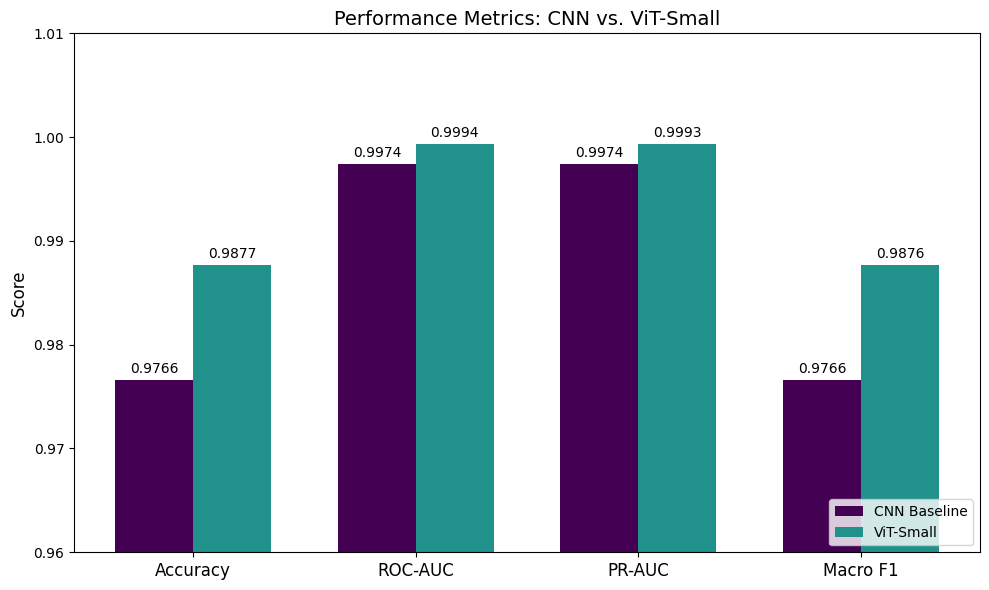

In [20]:
# 1. Performance Metrics Comparison
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, cnn_scores, width, label='CNN Baseline', color='#440154')
rects2 = ax.bar(x + width/2, vit_scores, width, label='ViT-Small', color='#21918c')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Performance Metrics: CNN vs. ViT-Small', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0.96, 1.01) # Zoomed in to highlight difference
ax.legend(loc='lower right')

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

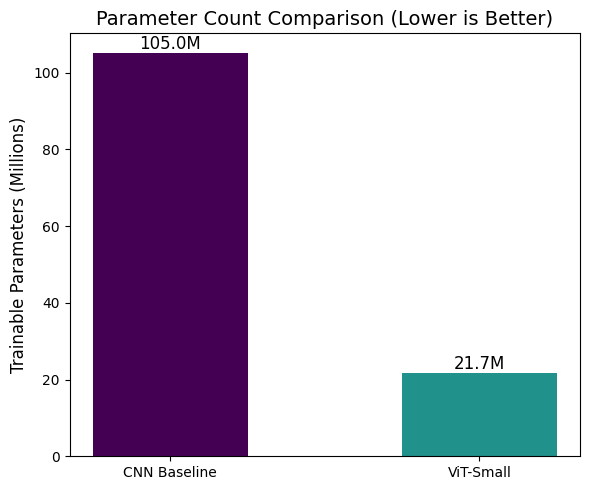

In [8]:
# 2. Parameter Efficiency Comparison
models = ['CNN Baseline', 'ViT-Small']
params = [105.0, vit_data['parameters']['trainable'] / 1e6]

fig, ax = plt.subplots(figsize=(6, 5))
rects = ax.bar(models, params, color=['#440154', '#21918c'], width=0.5)

ax.set_ylabel('Trainable Parameters (Millions)', fontsize=12)
ax.set_title('Parameter Count Comparison (Lower is Better)', fontsize=14)

for rect in rects:
    height = rect.get_height()
    ax.annotate(f'{height:.1f}M',
                xy=(rect.get_x() + rect.get_width() / 2, height - 1),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=12)

fig.tight_layout()
plt.show()

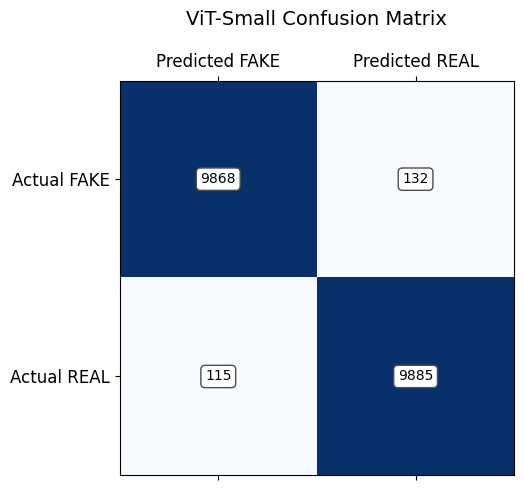

In [4]:
# 3. Confusion Matrix for ViT-Small
cm = vit_data['confusion_matrix']
cm_matrix = np.array([
    [cm['true_fake_pred_fake'], cm['true_fake_pred_real']],
    [cm['true_real_pred_fake'], cm['true_real_pred_real']]
])

fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.matshow(cm_matrix, cmap='Blues')

for (i, j), z in np.ndenumerate(cm_matrix):
    ax.text(j, i, f'{z}', ha='center', va='center', 
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='0.3'))

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted FAKE', 'Predicted REAL'], fontsize=12)
ax.set_yticklabels(['Actual FAKE', 'Actual REAL'], fontsize=12)
ax.set_title('ViT-Small Confusion Matrix', fontsize=14, pad=20)

fig.tight_layout()
plt.show()